# 01 - Exploratory Data Analysis: late delivery rate

Data: `data/processed/orders_clean.csv` produced by `src/data_prep.py`.
Each row is one **order item**, so every late rate below is the share of order items with `late_delivery_risk = 1`.
Charts are saved to `reports/figures/`.

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# The notebook runs from notebooks/, so the project root is one level up.
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))
from src.data_prep import load_processed

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

BAR_COLOR = "#2a78d6"        # one colour for every bar: each chart shows a single measure
REFERENCE_COLOR = "#52514e"  # grey for the overall-rate line and labels

plt.rcParams.update({
    "figure.dpi": 100,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": "#e5e4df",
    "axes.axisbelow": True,   # grid lines behind the bars
})
PERCENT = mticker.PercentFormatter(xmax=1, decimals=0)

In [ ]:
df = load_processed()
overall_rate = df["late_delivery_risk"].mean()
print(f"{len(df):,} order items in {df['order_id'].nunique():,} orders")
print(f"Overall late rate: {overall_rate:.1%}")

172,762 order items in 62,894 orders
Overall late rate: 57.3%


In [ ]:
def plot_late_rate(ax, column, min_items=0, label_bars=True):
    """Horizontal bars of the late rate per value of `column`, sorted, with the overall rate as a dashed line."""
    rates = df.groupby(column)["late_delivery_risk"].agg(["mean", "size"])
    rates = rates[rates["size"] >= min_items].sort_values("mean")

    ax.barh(rates.index.astype(str), rates["mean"], color=BAR_COLOR, height=0.6)
    ax.axvline(overall_rate, color=REFERENCE_COLOR, linestyle="--", linewidth=1,
               label=f"Overall ({overall_rate:.0%})")
    if label_bars:
        for y, rate in enumerate(rates["mean"]):
            ax.text(rate + 0.01, y, f"{rate:.0%}", va="center", color=REFERENCE_COLOR)
    ax.set_xlim(0, 1)
    ax.xaxis.set_major_formatter(PERCENT)
    ax.grid(axis="y", visible=False)
    ax.set_xlabel("Late delivery rate")
    ax.legend(loc="lower right", frameon=False)
    return rates


def save(fig, filename):
    """Save a figure to reports/figures/ and show it."""
    fig.savefig(FIGURES_DIR / filename, dpi=150, bbox_inches="tight")
    plt.show()

## 1. Late delivery rate overall

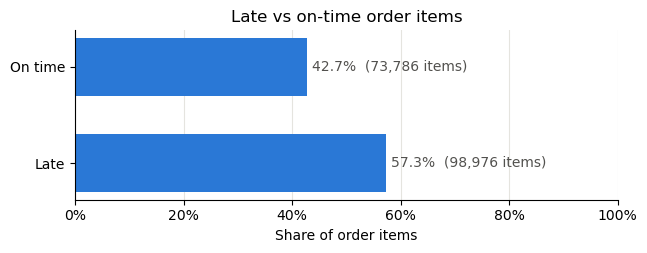

In [ ]:
counts = df["late_delivery_risk"].map({0: "On time", 1: "Late"}).value_counts()
shares = counts / counts.sum()

fig, ax = plt.subplots(figsize=(7, 2.2))
ax.barh(shares.index, shares.values, color=BAR_COLOR, height=0.6)
for y, (label, share) in enumerate(shares.items()):
    ax.text(share + 0.01, y, f"{share:.1%}  ({counts[label]:,} items)", va="center", color=REFERENCE_COLOR)
ax.set_xlim(0, 1)
ax.xaxis.set_major_formatter(PERCENT)
ax.grid(axis="y", visible=False)
ax.set_xlabel("Share of order items")
ax.set_title("Late vs on-time order items")
save(fig, "01_late_rate_overall.png")

172,762 order items: 57.3% late (98,976 items) vs 42.7% on time (73,786 items). This is the baseline — a model has to beat 57.3% accuracy from guessing "late" every time to be useful at all

## 2. Late delivery rate by shipping mode

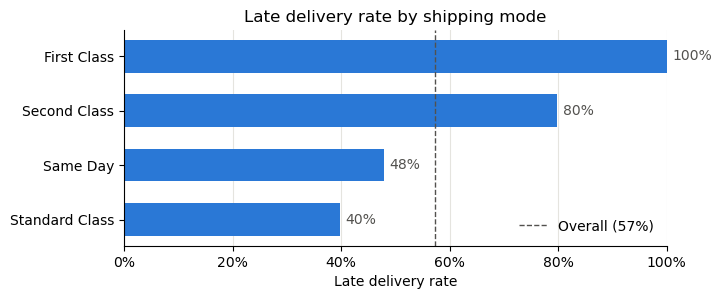

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.8))
plot_late_rate(ax, "shipping_mode")
ax.set_title("Late delivery rate by shipping mode")
save(fig, "02_late_rate_by_shipping_mode.png")

Late rate varies sharply by mode: First Class 100%, Second Class 80%, Same Day 48%, Standard Class 40%. This is by far the strongest single split seen in this EDA — but it's driven entirely by scheduled shipping days (see chart 7), since each mode maps to one fixed number of scheduled days.

## 3. Late delivery rate by market and order region

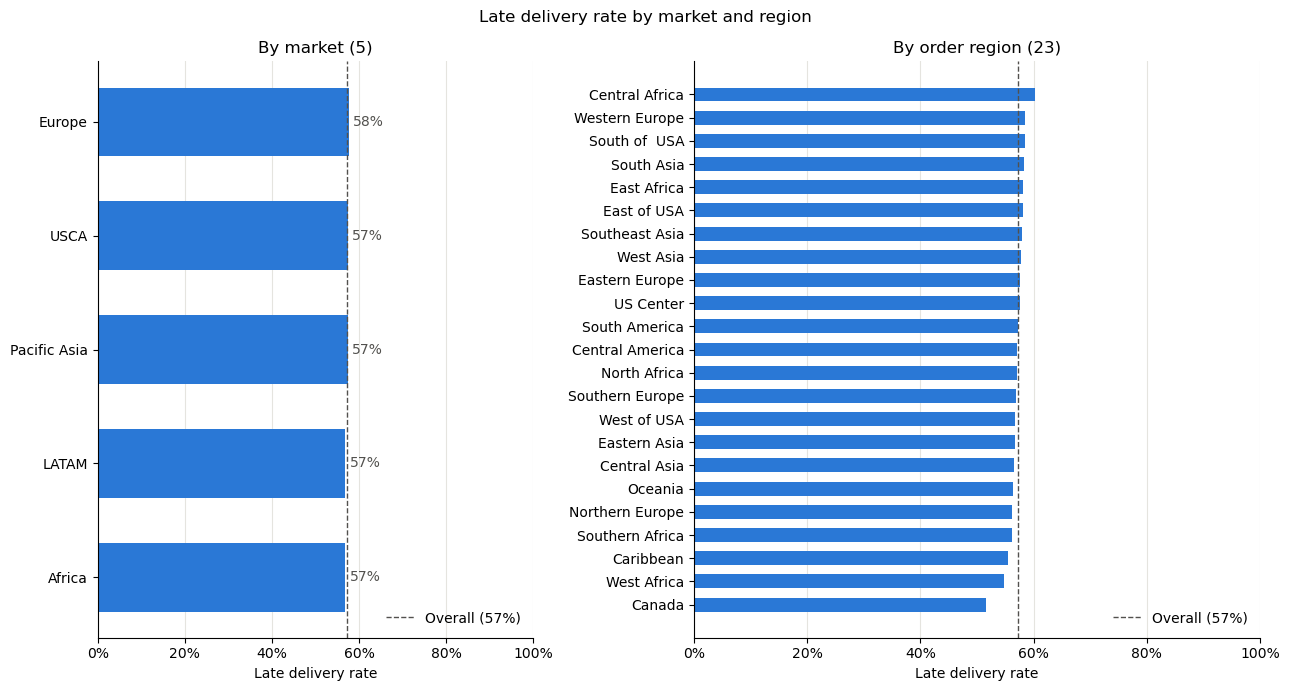

In [ ]:
fig, (ax_market, ax_region) = plt.subplots(
    1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [1, 1.3]})
plot_late_rate(ax_market, "market")
ax_market.set_title("By market (5)")
plot_late_rate(ax_region, "order_region", label_bars=False)
ax_region.set_title("By order region (23)")
fig.suptitle("Late delivery rate by market and region")
fig.tight_layout()
save(fig, "03_late_rate_by_market_region.png")

Both are close to the 57% baseline, but not perfectly flat. By market: Europe 58%, USCA/Pacific Asia/LATAM/Africa all ~57%. By region, the spread is wider — Central Africa is highest at ~61%, Canada is lowest at ~52%, and most other regions sit in a narrow 56–59% band. Geography has a mild effect at the region level but no dramatic outlier.

## 4. Late delivery rate by product category

Showing categories with at least 500 items; 27 smaller categories left out


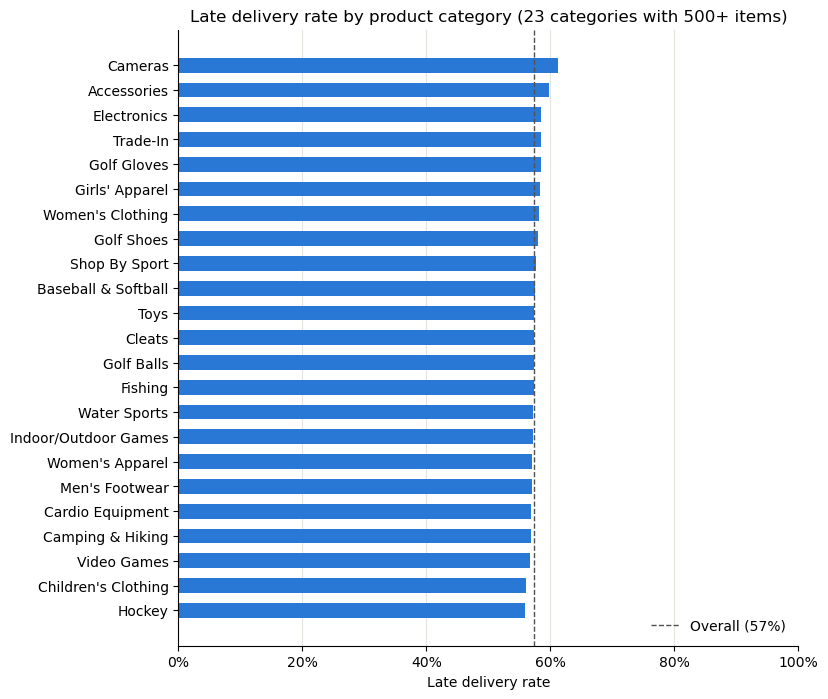

In [ ]:
MIN_ITEMS = 500  # smaller categories give unstable rates
n_small = (df["category_name"].value_counts() < MIN_ITEMS).sum()
print(f"Showing categories with at least {MIN_ITEMS} items; {n_small} smaller categories left out")

fig, ax = plt.subplots(figsize=(8, 8))
rates = plot_late_rate(ax, "category_name", min_items=MIN_ITEMS, label_bars=False)
ax.set_title(f"Late delivery rate by product category ({len(rates)} categories with {MIN_ITEMS}+ items)")
save(fig, "04_late_rate_by_category.png")

The 23 categories with 500+ items span roughly 56% (Hockey) to 62% (Cameras) — a real but modest spread of about 6 points around the baseline, not the sharp separation seen for shipping mode. No category stands out as a strong predictor on its own.

## 5. Late delivery rate by customer segment

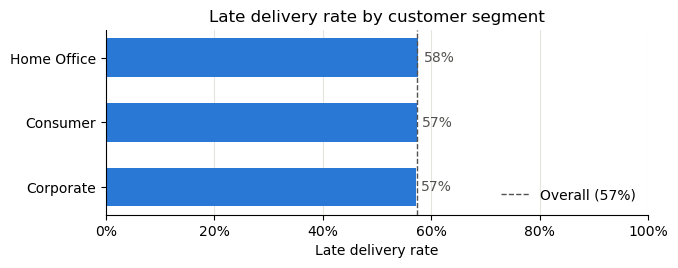

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.4))
plot_late_rate(ax, "customer_segment")
ax.set_title("Late delivery rate by customer segment")
save(fig, "05_late_rate_by_customer_segment.png")

Nearly flat: Home Office 58%, Consumer 57%, Corporate 57%. Segment has essentially no effect on late delivery rate.

## 6. Late delivery rate by order month

Months with the fewest order items:
order_date
2017-11    1955
2017-12    2030
2018-01    2037
Freq: M, Name: size, dtype: int64


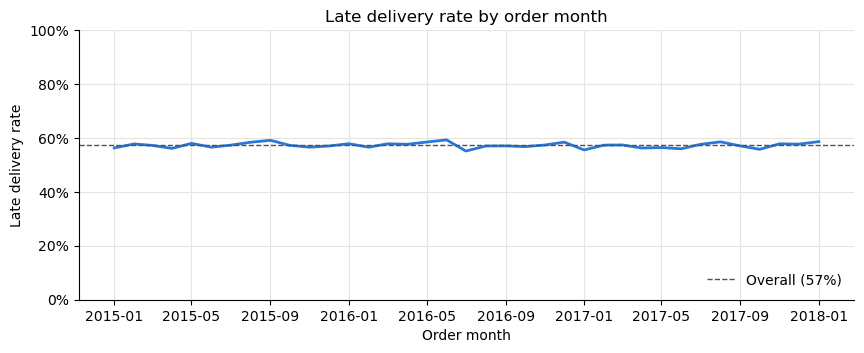

In [ ]:
by_month = df.groupby(df["order_date"].dt.to_period("M"))["late_delivery_risk"].agg(["mean", "size"])
print("Months with the fewest order items:")
print(by_month["size"].nsmallest(3))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.plot(by_month.index.to_timestamp(), by_month["mean"], color=BAR_COLOR, linewidth=2)
ax.axhline(overall_rate, color=REFERENCE_COLOR, linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.0%})")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PERCENT)
ax.set_ylabel("Late delivery rate")
ax.set_xlabel("Order month")
ax.legend(loc="lower right", frameon=False)
ax.set_title("Late delivery rate by order month")
save(fig, "06_late_rate_by_order_month.png")

The monthly rate oscillates in a tight band, roughly 55–60%, around the 57% baseline for the full Jan 2015–Jan 2018 range, with no upward or downward trend and no clear seasonal pattern. One dip to about 55% appears mid-2016. The three thinnest months (Nov 2017–Jan 2018, ~2,000 items each) fall at the right edge of the chart and don't show unusual swings despite the smaller sample.

## 7. Scheduled shipping days vs late delivery rate

                             mean    size
scheduled_shipping_days                  
0                        0.479285    9293
1                        1.000000   26512
2                        0.798290   33806
4                        0.397699  103151


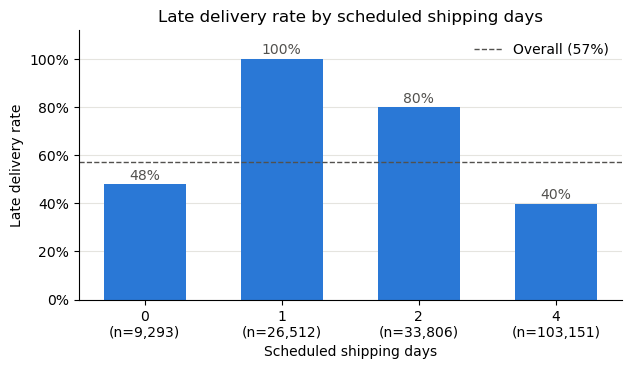

In [ ]:
by_days = df.groupby("scheduled_shipping_days")["late_delivery_risk"].agg(["mean", "size"])
print(by_days)

fig, ax = plt.subplots(figsize=(7, 3.5))
# Labels are text, so days with no orders (e.g. 3) leave no gap; item counts go under each label.
labels = [f"{days}\n(n={size:,})" for days, size in zip(by_days.index, by_days["size"])]
ax.bar(labels, by_days["mean"], color=BAR_COLOR, width=0.6)
for x, rate in enumerate(by_days["mean"]):
    ax.text(x, rate + 0.02, f"{rate:.0%}", ha="center", color=REFERENCE_COLOR)
ax.axhline(overall_rate, color=REFERENCE_COLOR, linestyle="--", linewidth=1,
           label=f"Overall ({overall_rate:.0%})")
ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(PERCENT)
ax.grid(axis="x", visible=False)
ax.set_xlabel("Scheduled shipping days")
ax.set_ylabel("Late delivery rate")
ax.legend(loc="upper right", frameon=False)
ax.set_title("Late delivery rate by scheduled shipping days")
save(fig, "07_late_rate_by_scheduled_days.png")

Late rate by scheduled days: 0 days → 48% (n=9,293), 1 day → 100% (n=26,512), 2 days → 80% (n=33,806), 4 days → 40% (n=103,151). Note 3 days has zero orders — it's simply absent from the data, not a small group. This chart is the real driver behind chart 2: shipping mode is just a label for these same four day-counts, so the two columns carry identical information and only one should go into the model.